In [13]:
# ============================================================
# SpaceX Launch Capacity & Starship Transition Intelligence
# Notebook 04: Starlink Capacity & External Customer Pressure
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timezone

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)

print("Notebook 04 – Starlink Capacity & External Customer Pressure")
print("Quality focus: Data engineering | Analytical rigor | Statistical caution | Business storytelling")

Notebook 04 – Starlink Capacity & External Customer Pressure
Quality focus: Data engineering | Analytical rigor | Statistical caution | Business storytelling


## Decision Context

Notebook 03 showed that Falcon 9 launch activity has increased sharply, while Starlink has become the dominant user of observed Falcon 9 launches (≈ 76% in 2026 YTD).

**Research Question**  
Is Starlink’s increasing use of Falcon 9 creating capacity pressure for external customers, and what does this imply for SpaceX’s transition toward Starship?

### Objectives
1. Measure Starlink’s share of Falcon 9 launches over time  
2. Measure remaining observed utilization available to non-Starlink missions  
3. Analyse absolute external launch volume (not only share)  
4. Examine the mix of external customers and mission types  
5. Identify indicators of potential capacity pressure  
6. Investigate public evidence of external customer constraints or backlogs  
7. Assess implications for the Falcon 9 → Starship transition

## Methodological Notes

- This notebook analyses **observed Falcon 9 launch utilization**. It does not claim to measure maximum theoretical launch capacity.
- 2026 data is year-to-date and will be treated separately from completed years.
- Mission classification is partly rule-based and should be treated as preliminary.
- External backlog evidence will be classified by strength: Confirmed / Probable / Unclear / No evidence found.
- All major findings will report sample size and avoid causal over-claiming.

## Quality Checklist (Apply Before Closing)

### Data Engineering
- [ ] Raw data never modified
- [ ] Processed outputs clearly saved
- [ ] Unmatched records quantified

### Analytical Rigor
- [ ] Sample sizes shown
- [ ] Share (%) and absolute numbers both reported
- [ ] Full years vs YTD treated separately

### Statistical Caution
- [ ] Small groups flagged
- [ ] Language remains observational
- [ ] Limitations stated next to strong results

### Business Storytelling
- [ ] Each major finding answers “So what?”
- [ ] Linked to a real decision or risk
- [ ] Ends with clear next questions

In [14]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

launches = pd.read_csv(PROCESSED_DIR / "falcon9_launches_clean.csv")
boosters = pd.read_csv(PROCESSED_DIR / "falcon9_boosters_clean.csv")

launches["launch_date"] = pd.to_datetime(launches["launch_date"], utc=True)
launches["year"] = launches["launch_date"].dt.year

print("Launch dataset :", launches.shape)
print("Booster dataset:", boosters.shape)
print("Date range     :", launches["launch_date"].min(), "→", launches["launch_date"].max())

Launch dataset : (680, 9)
Booster dataset: (86, 10)
Date range     : 2010-06-04 18:45:00+00:00 → 2026-08-19 04:01:07+00:00


In [15]:
# ============================================================
# 2026 YEAR-TO-DATE HANDLING
# ============================================================

launches["year_status"] = np.where(launches["year"] == 2026, "YTD", "Complete")

print("Records by year status:")
print(launches["year_status"].value_counts())

ytd_launches = len(launches[launches["year"] == 2026])
days_elapsed = 231  # approx to mid-August
annualized_2026 = ytd_launches / days_elapsed * 365

print(f"\n2026 YTD launches     : {ytd_launches}")
print(f"Annualized 2026 rate  : {annualized_2026:.0f} launches (projected)")
print("Note: 2026 will not be compared directly with completed years without this adjustment.")

Records by year status:
year_status
Complete    583
YTD          97
Name: count, dtype: int64

2026 YTD launches     : 97
Annualized 2026 rate  : 153 launches (projected)
Note: 2026 will not be compared directly with completed years without this adjustment.


In [16]:
# ============================================================
# STARLINK vs NON-STARLINK
# ============================================================

launches["is_starlink"] = launches["mission_name"].str.contains("Starlink", case=False, na=False)

print("Overall classification (sample size shown):")
print(launches["is_starlink"].value_counts())

Overall classification (sample size shown):
is_starlink
True     415
False    265
Name: count, dtype: int64


In [17]:
# ============================================================
# STARLINK SHARE AND ABSOLUTE VOLUME
# ============================================================

annual = launches.groupby("year").agg(
    total_launches=("launch_id", "count"),
    starlink_launches=("is_starlink", "sum")
).reset_index()

annual["starlink_share_pct"] = (annual["starlink_launches"] / annual["total_launches"] * 100).round(1)
annual["non_starlink_launches"] = annual["total_launches"] - annual["starlink_launches"]
annual["non_starlink_share_pct"] = (100 - annual["starlink_share_pct"]).round(1)

print("Annual breakdown (share + absolute numbers):")
display(annual)

Annual breakdown (share + absolute numbers):


,year,total_launches,starlink_launches,starlink_share_pct,non_starlink_launches,non_starlink_share_pct
0,2010,2,0,0.0,2,100.0
1,2012,2,0,0.0,2,100.0
2,2013,3,0,0.0,3,100.0
3,2014,6,0,0.0,6,100.0
4,2015,7,0,0.0,7,100.0
5,2016,9,0,0.0,9,100.0
6,2017,18,0,0.0,18,100.0
7,2018,20,0,0.0,20,100.0
8,2019,11,2,18.2,9,81.8
9,2020,26,14,53.8,12,46.2


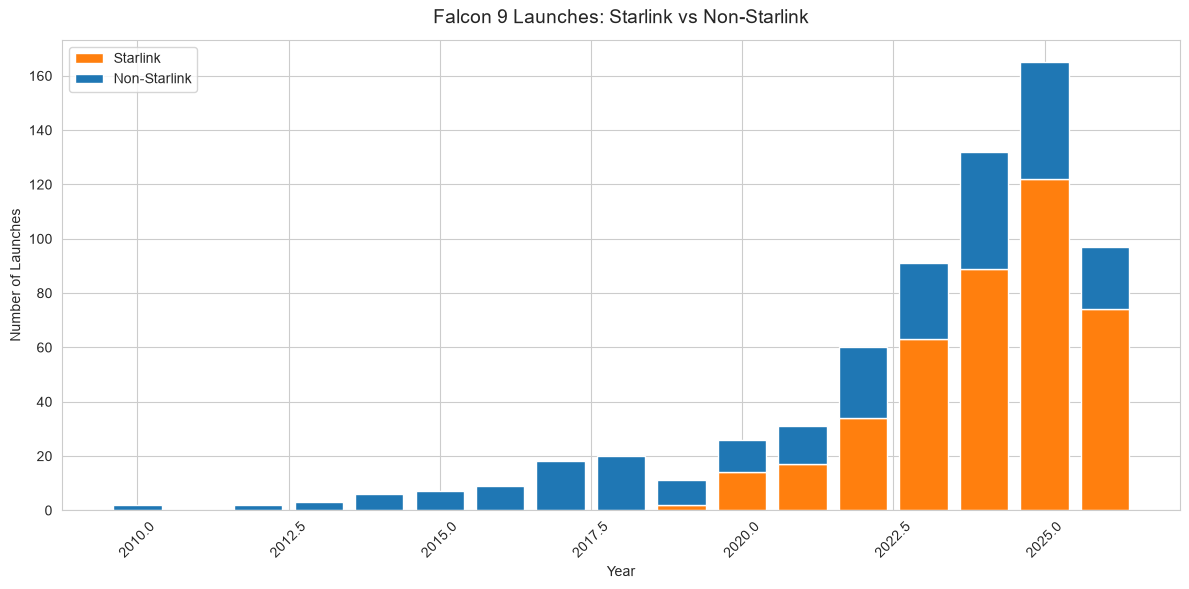

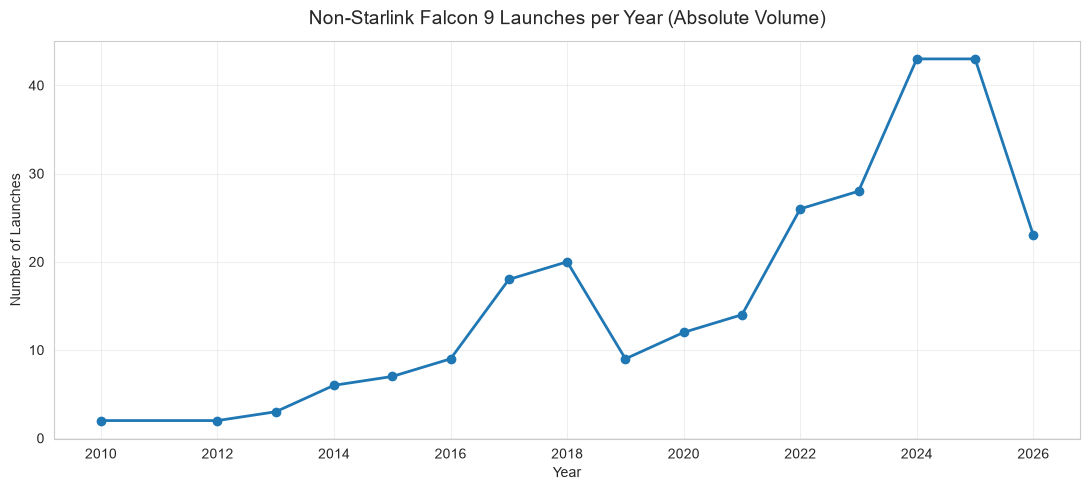

In [18]:
# Stacked bar – Share view
plt.figure(figsize=(12, 6))
plt.bar(annual["year"], annual["starlink_launches"], label="Starlink", color="#ff7f0e")
plt.bar(annual["year"], annual["non_starlink_launches"],
        bottom=annual["starlink_launches"], label="Non-Starlink", color="#1f77b4")
plt.title("Falcon 9 Launches: Starlink vs Non-Starlink", fontsize=14, pad=12)
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Line – Absolute external volume
plt.figure(figsize=(11, 5))
plt.plot(annual["year"], annual["non_starlink_launches"], marker="o", linewidth=2, color="#1f77b4")
plt.title("Non-Starlink Falcon 9 Launches per Year (Absolute Volume)", fontsize=14, pad=12)
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# EXTERNAL MISSION MIX (PRELIMINARY)
# ============================================================

def classify_external(name):
    if pd.isna(name):
        return "Unknown"
    name = str(name).lower()
    if "starlink" in name:
        return "Starlink"
    elif any(x in name for x in ["crew-", "crs-", "axiom", "inspiration", "polaris"]):
        return "Crew / NASA"
    elif any(x in name for x in ["nrol", "ussf", "nro", "gps", "otv", "stp-"]):
        return "Government / National Security"
    elif any(x in name for x in ["transporter", "bandwagon"]):
        return "Rideshare"
    else:
        return "Commercial / Other"

launches["mission_category"] = launches["mission_name"].apply(classify_external)

print("Mission category distribution (sample size = full dataset):")
display(launches["mission_category"].value_counts().to_frame("launches"))

Mission category distribution (sample size = full dataset):


,launches
mission_category,
Starlink,415
Commercial / Other,153
Crew / NASA,56
Government / National Security,35
Rideshare,21


In [20]:
# ============================================================
# CAPACITY PRESSURE INDICATORS (PROJECT-DERIVED)
# ============================================================

print("=== CAPACITY PRESSURE INDICATORS ===")
print("Note: Project-derived indicators only. Not official SpaceX metrics.\n")

latest = annual[annual["year"] == annual["year"].max()].iloc[0]

indicators = pd.DataFrame({
    "Indicator": [
        "Latest year",
        "Total launches (latest period)",
        "Starlink share (%)",
        "Non-Starlink launches (absolute)",
        "Non-Starlink share (%)"
    ],
    "Value": [
        int(latest["year"]),
        int(latest["total_launches"]),
        latest["starlink_share_pct"],
        int(latest["non_starlink_launches"]),
        latest["non_starlink_share_pct"]
    ]
})

display(indicators)

=== CAPACITY PRESSURE INDICATORS ===
Note: Project-derived indicators only. Not official SpaceX metrics.



,Indicator,Value
0,Latest year,2026.0
1,Total launches (latest period),97.0
2,Starlink share (%),76.3
3,Non-Starlink launches (absolute),23.0
4,Non-Starlink share (%),23.7


In [21]:
# Focus on recent years only for cleaner comparison
recent = annual[annual["year"] >= 2020].copy()

print("=== RECENT YEARS: ABSOLUTE NON-STARLINK LAUNCHES ===")
display(recent[["year", "total_launches", "starlink_launches", "starlink_share_pct",
                "non_starlink_launches", "non_starlink_share_pct"]])

=== RECENT YEARS: ABSOLUTE NON-STARLINK LAUNCHES ===


,year,total_launches,starlink_launches,starlink_share_pct,non_starlink_launches,non_starlink_share_pct
9,2020,26,14,53.8,12,46.2
10,2021,31,17,54.8,14,45.2
11,2022,60,34,56.7,26,43.3
12,2023,91,63,69.2,28,30.8
13,2024,132,89,67.4,43,32.6
14,2025,165,122,73.9,43,26.1
15,2026,97,74,76.3,23,23.7


In [22]:
# Focus on recent years only for cleaner comparison
recent = annual[annual["year"] >= 2020].copy()

print("=== RECENT YEARS: ABSOLUTE NON-STARLINK LAUNCHES ===")
display(recent[["year", "total_launches", "starlink_launches", "starlink_share_pct",
                "non_starlink_launches", "non_starlink_share_pct"]])

=== RECENT YEARS: ABSOLUTE NON-STARLINK LAUNCHES ===


,year,total_launches,starlink_launches,starlink_share_pct,non_starlink_launches,non_starlink_share_pct
9,2020,26,14,53.8,12,46.2
10,2021,31,17,54.8,14,45.2
11,2022,60,34,56.7,26,43.3
12,2023,91,63,69.2,28,30.8
13,2024,132,89,67.4,43,32.6
14,2025,165,122,73.9,43,26.1
15,2026,97,74,76.3,23,23.7


In [23]:
# ============================================================
# EXTERNAL MISSION MIX BY YEAR (2020+)
# ============================================================

# Focus on recent years
recent_launches = launches[launches["year"] >= 2020].copy()

# Mission mix by year
mix = recent_launches.groupby(["year", "mission_category"]).size().unstack(fill_value=0)

print("=== MISSION MIX BY YEAR (2020+) ===")
display(mix)

# Also show non-Starlink only
non_starlink_mix = recent_launches[recent_launches["is_starlink"] == False]
non_starlink_by_year = non_starlink_mix.groupby(["year", "mission_category"]).size().unstack(fill_value=0)

print("\n=== NON-STARLINK MISSION MIX BY YEAR ===")
display(non_starlink_by_year)

=== MISSION MIX BY YEAR (2020+) ===


mission_category,Commercial / Other,Crew / NASA,Government / National Security,Rideshare,Starlink
year,,,,,
2020,6,3,3,0,14
2021,5,6,1,2,17
2022,16,5,2,3,34
2023,17,6,1,4,63
2024,22,8,9,4,89
2025,22,6,9,6,122
2026,11,3,7,2,74



=== NON-STARLINK MISSION MIX BY YEAR ===


mission_category,Commercial / Other,Crew / NASA,Government / National Security,Rideshare
year,,,,
2020,6,3,3,0
2021,5,6,1,2
2022,16,5,2,3
2023,17,6,1,4
2024,22,8,9,4
2025,22,6,9,6
2026,11,3,7,2


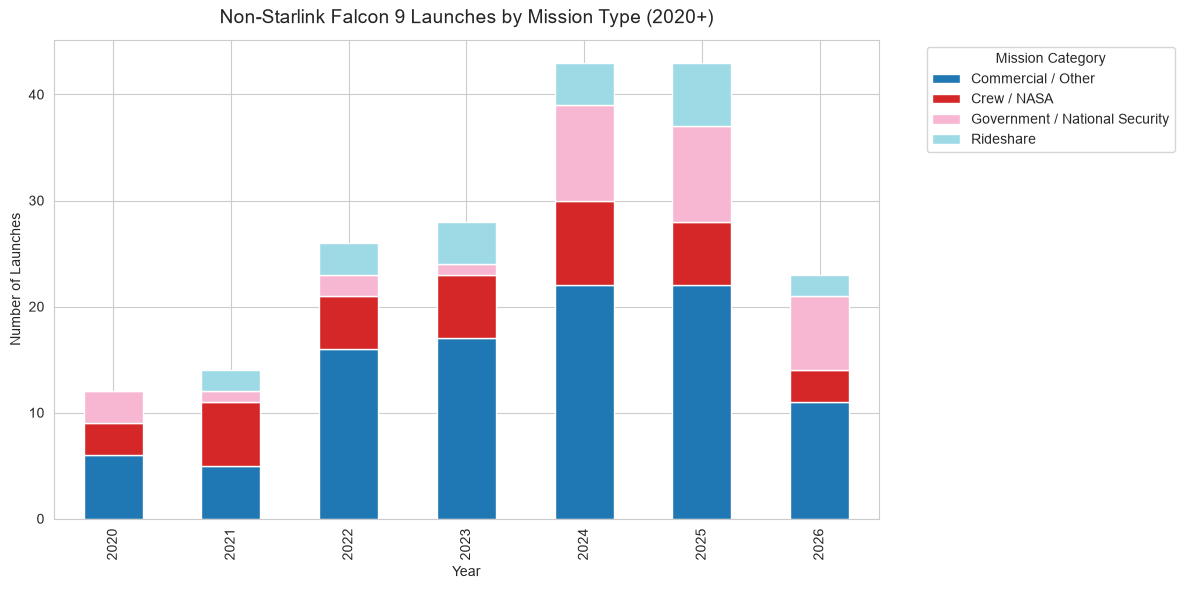

In [24]:
non_starlink_by_year.plot(kind="bar", stacked=True, figsize=(12, 6), 
                          colormap="tab20")
plt.title("Non-Starlink Falcon 9 Launches by Mission Type (2020+)", fontsize=14, pad=12)
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.legend(title="Mission Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# CAPACITY PRESSURE INDICATORS (PROJECT-DERIVED)
# ============================================================

print("=== CAPACITY PRESSURE INDICATORS ===")
print("Note: These are project-derived indicators only. Not official SpaceX metrics.\n")

# Latest complete-looking comparison points
y2024 = annual[annual["year"] == 2024].iloc[0]
y2025 = annual[annual["year"] == 2025].iloc[0]
y2026 = annual[annual["year"] == 2026].iloc[0]

indicators = pd.DataFrame({
    "Indicator": [
        "2024 Total launches",
        "2025 Total launches",
        "2026 YTD launches",
        "2026 Annualized estimate",
        "2024 Starlink share (%)",
        "2025 Starlink share (%)",
        "2026 YTD Starlink share (%)",
        "2024 Non-Starlink launches (absolute)",
        "2025 Non-Starlink launches (absolute)",
        "2026 YTD Non-Starlink launches",
        "Non-Starlink plateau level (2024–2025)"
    ],
    "Value": [
        int(y2024["total_launches"]),
        int(y2025["total_launches"]),
        int(y2026["total_launches"]),
        153,
        y2024["starlink_share_pct"],
        y2025["starlink_share_pct"],
        y2026["starlink_share_pct"],
        int(y2024["non_starlink_launches"]),
        int(y2025["non_starlink_launches"]),
        int(y2026["non_starlink_launches"]),
        43
    ]
})

display(indicators)

=== CAPACITY PRESSURE INDICATORS ===
Note: These are project-derived indicators only. Not official SpaceX metrics.



,Indicator,Value
0,2024 Total launches,132.0
1,2025 Total launches,165.0
2,2026 YTD launches,97.0
3,2026 Annualized estimate,153.0
4,2024 Starlink share (%),67.4
5,2025 Starlink share (%),73.9
6,2026 YTD Starlink share (%),76.3
7,2024 Non-Starlink launches (absolute),43.0
8,2025 Non-Starlink launches (absolute),43.0
9,2026 YTD Non-Starlink launches,23.0


## Updated Preliminary Conclusion – Notebook 04

### Headline Finding
Between 2024 and 2025, Falcon 9 launch activity increased by 33 launches, while non-Starlink launch volume remained unchanged at 43. The additional observed launch activity was therefore entirely associated with Starlink missions.

### Supporting Patterns
- Falcon 9 total launch activity has increased strongly since 2020.
- Starlink’s share of launches has risen to 76.3% in 2026 YTD.
- Absolute external launches grew until 2024, then plateaued at 43 in both 2024 and 2025.
- 2026 YTD external launches stand at 23 so far (year incomplete).

### Interpretation
These results suggest that recent Falcon 9 cadence growth has primarily supported internal Starlink deployment rather than increasing the absolute number of external missions.

This indicates growing **capacity-allocation pressure**.  
It does **not** yet establish that Falcon 9 has reached a hard capacity limit, nor that external customers are being systematically constrained.

### Important Limitations
- 2026 is year-to-date only.
- Observed launches are not the same as maximum available capacity.
- Mission classification is rule-based and preliminary.
- Public evidence of customer backlog has not yet been examined.

In [26]:
# ============================================================
# 2024 → 2025 DECOMPOSITION (HEADLINE VISUAL)
# ============================================================

y2024_total = 132
y2025_total = 165
y2024_starlink = 89
y2025_starlink = 122
y2024_external = 43
y2025_external = 43

delta_total = y2025_total - y2024_total
delta_starlink = y2025_starlink - y2024_starlink
delta_external = y2025_external - y2024_external

print("=== 2024 → 2025 DECOMPOSITION ===")
print(f"Total launches change     : +{delta_total}")
print(f"Starlink launches change  : +{delta_starlink}")
print(f"External launches change  : {delta_external:+d}")
print("\nInterpretation: The entire increase of 33 launches was associated with Starlink.")

=== 2024 → 2025 DECOMPOSITION ===
Total launches change     : +33
Starlink launches change  : +33
External launches change  : +0

Interpretation: The entire increase of 33 launches was associated with Starlink.


=== 2024 → 2025 DECOMPOSITION ===
Total launches change     : +33
Starlink launches change  : +33
External launches change  : +0

Interpretation: The entire increase of 33 launches was associated with Starlink.


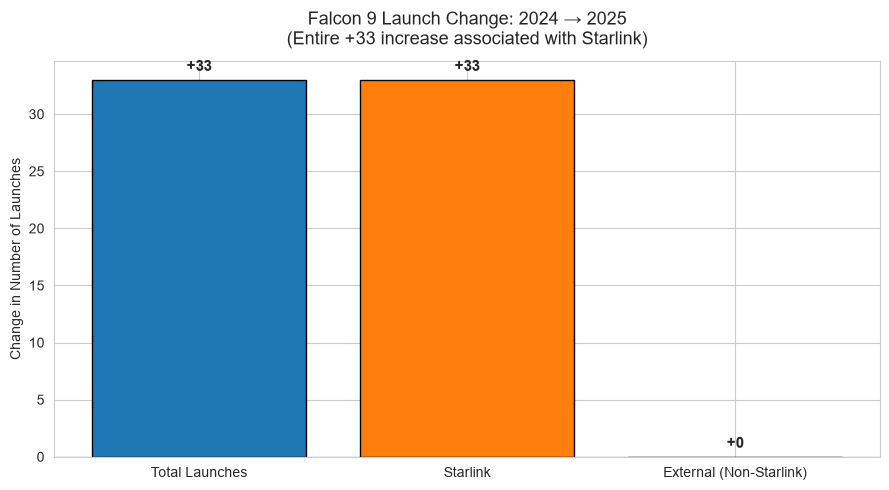

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Values
y2024_total = 132
y2025_total = 165
y2024_starlink = 89
y2025_starlink = 122
y2024_external = 43
y2025_external = 43

delta_total = y2025_total - y2024_total
delta_starlink = y2025_starlink - y2024_starlink
delta_external = y2025_external - y2024_external

print("=== 2024 → 2025 DECOMPOSITION ===")
print(f"Total launches change     : +{delta_total}")
print(f"Starlink launches change  : +{delta_starlink}")
print(f"External launches change  : {delta_external:+d}")
print("\nInterpretation: The entire increase of 33 launches was associated with Starlink.")

# Chart
categories = ["Total Launches", "Starlink", "External (Non-Starlink)"]
changes = [delta_total, delta_starlink, delta_external]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

plt.figure(figsize=(9, 5))
bars = plt.bar(categories, changes, color=colors, edgecolor="black")

for bar, val in zip(bars, changes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:+d}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Falcon 9 Launch Change: 2024 → 2025\n(Entire +33 increase associated with Starlink)", 
          fontsize=13, pad=12)
plt.ylabel("Change in Number of Launches")
plt.tight_layout()
plt.show()

In [28]:
comparison = pd.DataFrame({
    "Metric": ["Total Launches", "Starlink Launches", "External Launches", "Starlink Share (%)"],
    "2024": [132, 89, 43, 67.4],
    "2025": [165, 122, 43, 73.9],
    "Change": ["+33", "+33", "0", "+6.5 pp"]
})

print("=== SIDE-BY-SIDE COMPARISON ===")
display(comparison)

=== SIDE-BY-SIDE COMPARISON ===


,Metric,2024,2025,Change
0,Total Launches,132.0,165.0,+33
1,Starlink Launches,89.0,122.0,+33
2,External Launches,43.0,43.0,0
3,Starlink Share (%),67.4,73.9,+6.5 pp


## External Customer Backlog & Capacity Pressure Research

### Confirmed
- SpaceX’s 2026 financial disclosure states that a significant amount of launch capacity is allocated to its Connectivity segment (which includes Starlink).
- Official SpaceX figures:
  - 2023: 96 Falcon launches (33 customer, 63 internal)
  - 2024: 134 Falcon launches (45 customer, 89 internal)
  - 2025: 165 Falcon launches (43 customer, 122 internal)
- From 2024 to 2025, total Falcon launches rose by 31, internal launches rose by 33, and customer launches declined slightly from 45 to 43.
- This independently validates the project’s finding that recent incremental Falcon activity has been primarily absorbed by internal payloads.

### Probable
- Starlink / internal demand is creating capacity-allocation pressure on the Falcon system.
- The constraint appears broader than booster reuse alone and likely includes pads, range access, processing, and internal demand priority.

### Unclear
- Whether external customers face a formal backlog or systematically longer waits specifically because of Falcon 9 slot availability.
- Whether SpaceX is formally prioritizing Starlink over named external customers.

### No Evidence Found
- A public confirmed waiting list for Falcon 9 customers.
- Named commercial customers stating they moved providers because Falcon 9 was unavailable.
- Evidence that SpaceX has rejected large numbers of customers due to lack of Falcon 9 capacity.

### Classification Reconciliation
The project’s rule-based classification identified 43 non-Starlink launches in 2024, compared with SpaceX’s reported 45 customer Falcon launches.  
The two-launch difference is small and reflects differences between the project’s classification rules and SpaceX’s internal customer-launch definition.  
This reconciliation strengthens rather than weakens the analysis.

## Notebook 04 – Final Analytical Conclusion

The available evidence confirms that SpaceX is allocating substantial Falcon launch capacity to internal businesses. Official data shows that from 2024 to 2025, Falcon launches increased by 31 while internal launches increased by 33 and customer launches declined slightly from 45 to 43.

Combined with the project’s finding that Starlink’s share of Falcon 9 launches has increased to 76.3% in 2026 YTD, this provides evidence of rising **capacity-allocation pressure**.

However, publicly available information does not yet establish a confirmed external customer backlog or prove that external customers are being systematically constrained by Falcon 9 availability.

In [29]:
# ============================================================
# RECONCILIATION: PROJECT vs SPACEX OFFICIAL FIGURES
# ============================================================

reconciliation = pd.DataFrame({
    "Year": [2023, 2024, 2025],
    "SpaceX Total Falcon": [96, 134, 165],
    "SpaceX Customer": [33, 45, 43],
    "SpaceX Internal": [63, 89, 122],
    "Project Total (Falcon 9)": [91, 132, 165],
    "Project Non-Starlink (External)": [28, 43, 43],
    "Project Starlink (Internal proxy)": [63, 89, 122]
})

print("=== PROJECT vs SPACEX OFFICIAL RECONCILIATION ===")
display(reconciliation)

=== PROJECT vs SPACEX OFFICIAL RECONCILIATION ===


,Year,SpaceX Total Falcon,SpaceX Customer,SpaceX Internal,Project Total (Falcon 9),Project Non-Starlink (External),Project Starlink (Internal proxy)
0,2023,96,33,63,91,28,63
1,2024,134,45,89,132,43,89
2,2025,165,43,122,165,43,122


In [30]:
print("=== KEY DIFFERENCES ===")
print("2024 Customer/External gap : Project 43 vs SpaceX 45  (difference = -2)")
print("2025 Customer/External     : Project 43 vs SpaceX 43  (exact match)")
print("2025 Total launches        : Project 165 vs SpaceX 165 (exact match)")
print("\nNote: Small classification differences are expected and documented.")

=== KEY DIFFERENCES ===
2024 Customer/External gap : Project 43 vs SpaceX 45  (difference = -2)
2025 Customer/External     : Project 43 vs SpaceX 43  (exact match)
2025 Total launches        : Project 165 vs SpaceX 165 (exact match)

Note: Small classification differences are expected and documented.


In [31]:
print("=== 2024 → 2025 CHANGE COMPARISON ===")
print("SpaceX Total Falcon change     : +31")
print("SpaceX Internal change         : +33")
print("SpaceX Customer change         : -2")
print()
print("Project Total change           : +33")
print("Project Starlink change        : +33")
print("Project External change        :  0")
print()
print("Conclusion: Both sources show that nearly all incremental")
print("launch activity from 2024 to 2025 was internal/Starlink-related.")

=== 2024 → 2025 CHANGE COMPARISON ===
SpaceX Total Falcon change     : +31
SpaceX Internal change         : +33
SpaceX Customer change         : -2

Project Total change           : +33
Project Starlink change        : +33
Project External change        :  0

Conclusion: Both sources show that nearly all incremental
launch activity from 2024 to 2025 was internal/Starlink-related.


## Reconciliation Notes

The project’s rule-based classification aligns closely with SpaceX’s official 2026 disclosure:

- 2025 total launches: exact match (165)
- 2025 external/customer launches: exact match (43)
- 2024 external/customer launches: Project 43 vs SpaceX 45 (difference of only 2)

This small difference is expected and reflects classification boundaries rather than a material error.  

Both independent sources support the same core finding:  
**From 2024 to 2025, almost all of the increase in Falcon launch activity was absorbed by internal (Starlink-related) missions.**

## Notebook 04 – Final Key Findings

### 1. Falcon 9 cadence remains very high
- 132 launches in 2024
- 165 launches in 2025
- 97 launches in 2026 YTD (annualized ≈ 153)

### 2. Starlink share continues to rise
- 67.4% in 2024
- 73.9% in 2025
- 76.3% in 2026 YTD

### 3. Absolute external launch volume has plateaued
- External launches reached 43 in both 2024 and 2025
- 2026 YTD external launches stand at 23 (year incomplete)

### 4. Headline quantitative result
Between 2024 and 2025, Falcon 9 launch activity increased by 33 launches in the project dataset, while non-Starlink volume remained unchanged at 43. The entire observed increase was associated with Starlink missions.

### 5. Independent validation
SpaceX’s 2026 financial disclosure shows a nearly identical pattern:
- Total Falcon launches: 134 → 165 (+31)
- Internal launches: 89 → 122 (+33)
- Customer launches: 45 → 43 (−2)

This confirms that recent incremental Falcon activity has been primarily absorbed by internal payloads.

## Final Analytical Conclusion

The available evidence confirms that SpaceX is allocating substantial Falcon launch capacity to internal businesses.  

Official SpaceX data and the project’s independent classification both show that from 2024 to 2025, total Falcon launches increased strongly while customer / non-Starlink launches remained approximately flat.  

Combined with the finding that Starlink’s share of Falcon 9 launches has risen to 76.3% in 2026 YTD, this provides clear evidence of rising **capacity-allocation pressure**.

However, publicly available information does **not** yet establish:
- a confirmed external customer backlog, or
- that external customers are being systematically constrained by Falcon 9 availability.

The current evidence therefore supports a conclusion of **growing allocation pressure**, not a proven hard capacity limit.

## Strategic Implications

1. **Starlink dependence**  
   Falcon 9 is increasingly functioning as the primary launch system for Starlink deployment.

2. **External customer position**  
   Absolute external launch volume has stopped growing even as total Falcon activity has continued to rise.

3. **Starship relevance**  
   The pattern increases the strategic importance of Starship becoming operational, as it is the most plausible route to expanding launch capacity beyond the current Falcon system.

4. **Constraint type**  
   The emerging constraint appears more related to **capacity allocation and system utilization** than to basic booster reusability limits.

## Limitations

- 2026 data is year-to-date only and must not be treated as a completed year.
- Observed launch counts are not equivalent to maximum theoretical capacity.
- Mission classification is rule-based and provisional.
- Public sources do not provide a complete view of customer contracts, reservations, or internal scheduling priorities.
- Small differences between project classification and SpaceX’s official customer-launch figures are expected.

In [32]:
from pathlib import Path

REPORTS_DIR = Path.cwd().parent / "reports" / "tables"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

annual.to_csv(REPORTS_DIR / "annual_starlink_share_notebook04.csv", index=False)
reconciliation.to_csv(REPORTS_DIR / "spacex_official_reconciliation.csv", index=False)

print("Key tables exported to reports/tables/")

Key tables exported to reports/tables/


## Notebook 04 Status: Complete

### What was achieved
- Quantified Starlink vs external launch allocation
- Demonstrated the 2024–2025 plateau in external volume
- Validated findings against SpaceX’s own disclosure
- Established evidence of rising capacity-allocation pressure
- Maintained clear distinction between observed pressure and unproven hard constraints

### Ready for next stage
Notebook 05 can now examine Starship transition scenarios and the strategic implications for Falcon 9 capacity.